In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import mlflow
import mlflow.pytorch
from sklearn.model_selection import train_test_split

sys.path.append(str(Path("..").resolve()))

from src.features import load_raw_data, split_features_target, build_preprocessor
from src.model import build_model
from src.train import train_model, get_device, set_seeds
from src.evaluate import (
    get_predictions,
    compute_metrics,
    compute_cost_analysis,
    plot_training_history,
    plot_roc_curve,
    plot_pr_curve,
    plot_confusion_matrix,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
)

SEED = 1312
FIGURES_DIR = Path("../docs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
df = load_raw_data(Path("../data/raw/telco_churn.csv"))
X, y = split_features_target(df)

preprocessor = build_preprocessor()
y_array = y.values

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y_array,
    test_size=0.2,
    random_state=SEED,
    stratify=y_array,
)

# fit apenas no treino !!
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

print(f"Treino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Churn no treino: {y_train.mean():.1%}")
print(f"Churn na validação: {y_val.mean():.1%}")

Treino: (5625, 44)
Validação: (1407, 44)
Churn no treino: 26.6%
Churn na validação: 26.6%


In [3]:
DB_PATH = Path("../models/mlflow.db").resolve()
MLFLOW_TRACKING_URI = f"sqlite:///{DB_PATH}"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("churn-mlp")

print("MLflow configurado:", MLFLOW_TRACKING_URI)
print("Experimento: churn-mlp")

2026/04/25 00:56:07 INFO mlflow.tracking.fluent: Experiment with name 'churn-mlp' does not exist. Creating a new experiment.


MLflow configurado: sqlite:///C:\Users\bruno\OneDrive\Estudos\Especialização\Postech_MLE\modulo_01\Projeto-Churn-TC01\models\mlflow.db
Experimento: churn-mlp


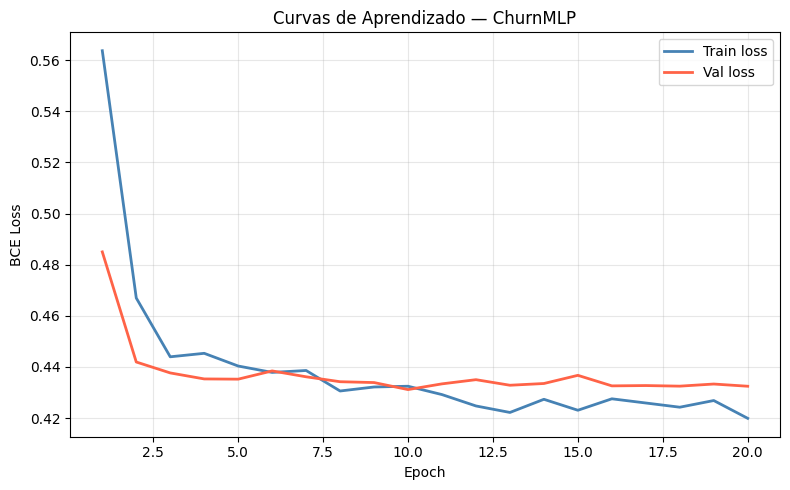

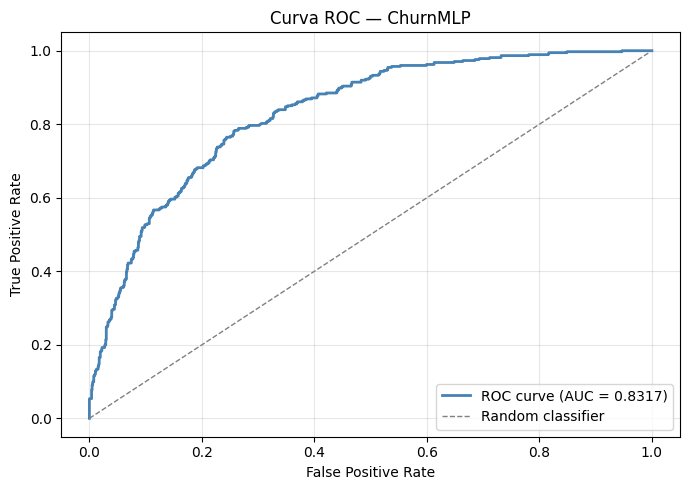

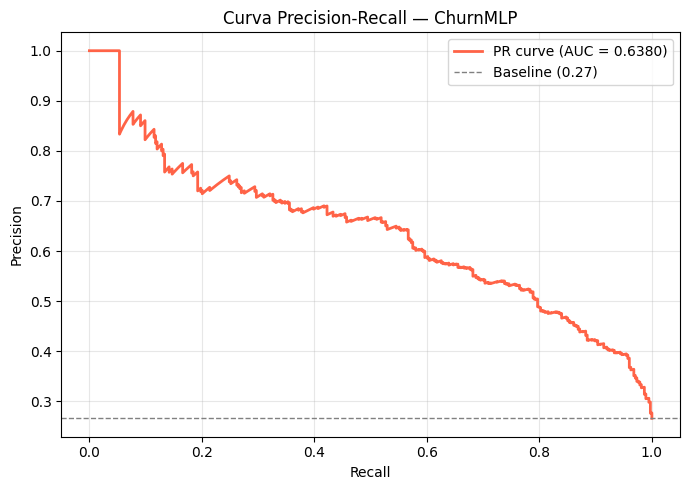

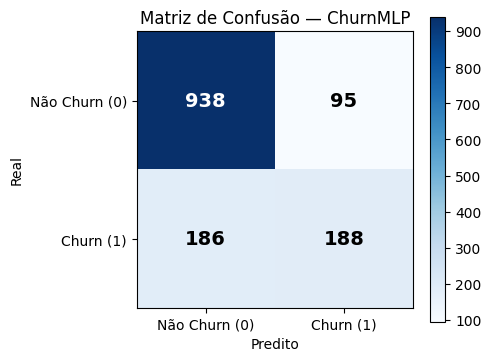

2026/04/25 01:03:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 01:03:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/25 01:04:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



ROC-AUC:  0.8317
PR-AUC:   0.6380
F1:       0.5723
Recall:   0.5027
Economia: R$89.250


In [ ]:
# Hiperparâmetros do experimento
HIDDEN_DIMS   = [64, 32, 16]
DROPOUT_RATE  = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
MAX_EPOCHS    = 100
PATIENCE      = 10

with mlflow.start_run(run_name="ChurnMLP_v1"):
    
    mlflow.log_params({
        "hidden_dims":   str(HIDDEN_DIMS),
        "dropout_rate":  DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size":    BATCH_SIZE,
        "max_epochs":    MAX_EPOCHS,
        "patience":      PATIENCE,
        "seed":          SEED,
        "input_dim":     X_train.shape[1],
        "n_train":       X_train.shape[0],
        "n_val":         X_val.shape[0],
    })

    model, history = train_model(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        input_dim=X_train.shape[1],
        hidden_dims=HIDDEN_DIMS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )

    for epoch, (tl, vl) in enumerate(
        zip(history["train_loss"], history["val_loss"]), start=1
    ):
        mlflow.log_metrics({"train_loss": tl, "val_loss": vl}, step=epoch)

    device = get_device()
    y_proba, y_pred = get_predictions(model, X_val, device)
    metrics = compute_metrics(y_val, y_proba, y_pred)
    cost    = compute_cost_analysis(y_val, y_pred)

    mlflow.log_metrics({
        "roc_auc":   metrics["roc_auc"],
        "pr_auc":    metrics["pr_auc"],
        "f1":        metrics["f1"],
        "recall":    metrics["recall"],
        "precision": metrics["precision"],
        "savings":   cost["savings"],
    })

    plot_training_history(history, save_path=FIGURES_DIR / "training_history.png")
    plot_roc_curve(y_val, y_proba, save_path=FIGURES_DIR / "roc_curve.png")
    plot_pr_curve(y_val, y_proba,  save_path=FIGURES_DIR / "pr_curve.png")
    plot_confusion_matrix(y_val, y_pred, save_path=FIGURES_DIR / "confusion_matrix.png")

    mlflow.log_artifacts(str(FIGURES_DIR), artifact_path="figures")

    mlflow.pytorch.log_model(model, artifact_path="model")

    print(f"\nROC-AUC:  {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:   {metrics['pr_auc']:.4f}")
    print(f"F1:       {metrics['f1']:.4f}")
    print(f"Recall:   {metrics['recall']:.4f}")
    print(f"Economia: R${cost['savings']:,.0f}".replace(",", "."))

In [5]:
import pandas as pd

# Carregar runs do MLflow para comparação
client = mlflow.tracking.MlflowClient()

# Experimento baselines
exp_baseline = client.get_experiment_by_name("churn-baselines")
exp_mlp      = client.get_experiment_by_name("churn-mlp")

runs_baseline = client.search_runs(exp_baseline.experiment_id)
runs_mlp      = client.search_runs(exp_mlp.experiment_id)

rows = []
for run in runs_baseline:
    rows.append({
        "Modelo":   run.data.params.get("model", run.info.run_name),
        "ROC-AUC":  run.data.metrics.get("roc_auc_mean", float("nan")),
        "PR-AUC":   run.data.metrics.get("pr_auc_mean",  float("nan")),
        "F1":       run.data.metrics.get("f1_mean",      float("nan")),
        "Recall":   run.data.metrics.get("recall_mean",  float("nan")),
    })

for run in runs_mlp:
    rows.append({
        "Modelo":  run.info.run_name,
        "ROC-AUC": run.data.metrics.get("roc_auc", float("nan")),
        "PR-AUC":  run.data.metrics.get("pr_auc",  float("nan")),
        "F1":      run.data.metrics.get("f1",       float("nan")),
        "Recall":  run.data.metrics.get("recall",   float("nan")),
    })

df_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
df_results = df_results.round(4).reset_index(drop=True)

print("\n=== Tabela Comparativa de Modelos ===")
print(df_results.to_string(index=False))


=== Tabela Comparativa de Modelos ===
            Modelo  ROC-AUC  PR-AUC     F1  Recall
LogisticRegression   0.8450  0.4835 0.6023  0.5570
       ChurnMLP_v1   0.8317  0.6380 0.5723  0.5027
   DummyClassifier   0.5000  0.2658 0.0000  0.0000


In [ ]:
# uv run jupyter notebook notebooks/03_mlp.ipynb
# uv run mlflow ui --backend-store-uri sqlite:///models/mlflow.db
# http://localhost:5000